In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
COLORS = ['#2E5EAA', '#F2A541', '#5FAD56', '#D64550', '#8E6C88']

In [8]:
df = pd.read_csv('C:\Data Analyst Training\Machine_learning_Project\Wather_Prediction\Machine_Learning_Project\Marketing-Data-Analysis\Data\Bank.csv', sep=';')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [9]:
def balanceator(x):
    if x < 72:
        return 'Class E'
    elif x >= 72 and x < 448:
        return 'Class D'
    elif x >= 448 and x < 1428:
        return 'Class C'
    elif x >= 1428 and x < df['balance'].quantile(0.99):
        return 'Class B'
    else:
        return 'Class A'

In [12]:
def wrangle(path):
    df = pd.read_csv(path, sep=';')
    
    bool_cols = ['y', 'default', 'housing', 'loan']
    df[bool_cols] = df[bool_cols] == 'yes'
    
    df['balance_class'] = df['balance'].apply(balanceator)
    
    df['previous_bool'] = df['previous'] != 0
    
    to_drop = ['previous', 'day', 'poutcome', 'pdays']
    df.drop(columns=to_drop, inplace=True)
    
    return df


In [13]:
df_pos = wrangle('C:\Data Analyst Training\Machine_learning_Project\Wather_Prediction\Machine_Learning_Project\Marketing-Data-Analysis\Data\Bank.csv')
df_pos.head()

,age,job,marital,education,default,balance,housing,loan,contact,month,duration,campaign,y,balance_class,previous_bool
0,58,management,married,tertiary,False,2143,True,False,unknown,may,261,1,False,Class B,False
1,44,technician,single,secondary,False,29,True,False,unknown,may,151,1,False,Class E,False
2,33,entrepreneur,married,secondary,False,2,True,True,unknown,may,76,1,False,Class E,False
3,47,blue-collar,married,unknown,False,1506,True,False,unknown,may,92,1,False,Class B,False
4,33,unknown,single,unknown,False,1,False,False,unknown,may,198,1,False,Class E,False


In [18]:
indipendent_x = df_pos.drop(columns = ["y", "balance", 'duration'])
dependent_y = df_pos['y']

In [19]:
oe = OrdinalEncoder()
indipendent_x = oe.fit_transform(indipendent_x)

In [20]:
independent_train, indipendent_test, dependent_train, dependent_test = train_test_split(indipendent_x, dependent_y, test_size=0.15, random_state=42, stratify=y)

In [21]:
dt = GridSearchCV(DecisionTreeClassifier(random_state=42), {}, n_jobs=-1, cv=10, refit="recall")
dt.fit(independent_train, dependent_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,{}
,scoring,None
,n_jobs,-1
,refit,'recall'
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


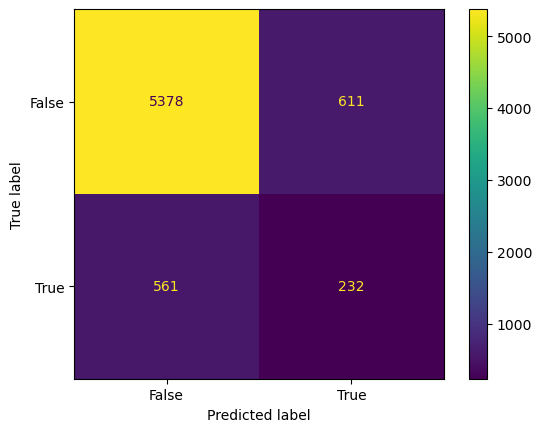

In [22]:
ConfusionMatrixDisplay.from_estimator(dt,indipendent_test,dependent_test)

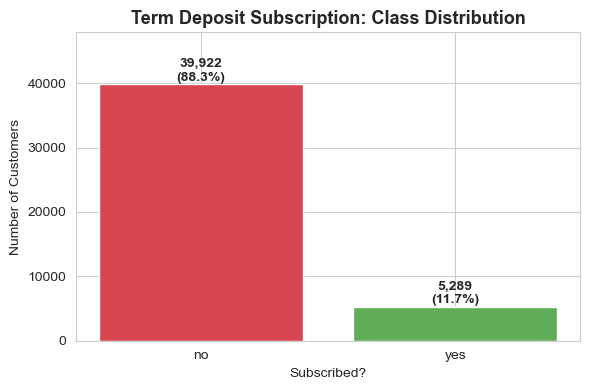

In [35]:
fig, ax = plt.subplots(figsize=(6,4))
counts = df['y'].value_counts()
bars = ax.bar(counts.index, counts.values, color=[COLORS[3], COLORS[2]])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+500, f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', fontweight='bold')
ax.set_title('Term Deposit Subscription: Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Subscribed?')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, max(counts.values)*1.2)
plt.tight_layout()
plt.savefig('chart_01_target_distribution.png', bbox_inches='tight')
plt.show()

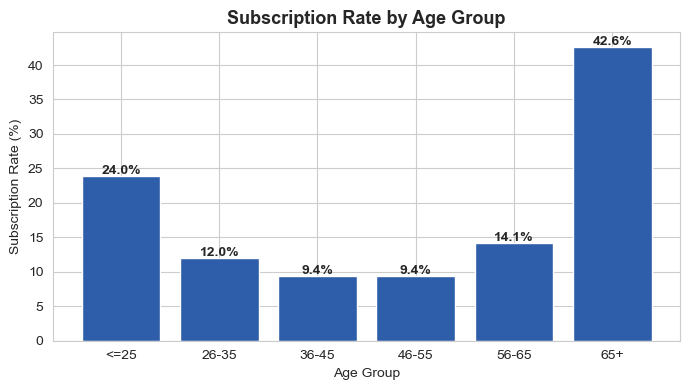

In [36]:
df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,55,65,100],
                          labels=['<=25','26-35','36-45','46-55','56-65','65+'])
age_rate = df.groupby('age_group', observed=True)['y'].apply(lambda s: (s=='yes').mean()*100)

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(age_rate.index.astype(str), age_rate.values, color=COLORS[0])
for bar, val in zip(bars, age_rate.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Subscription Rate by Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Subscription Rate (%)')
plt.tight_layout()
plt.savefig('chart_02_age_group.png', bbox_inches='tight')
plt.show()

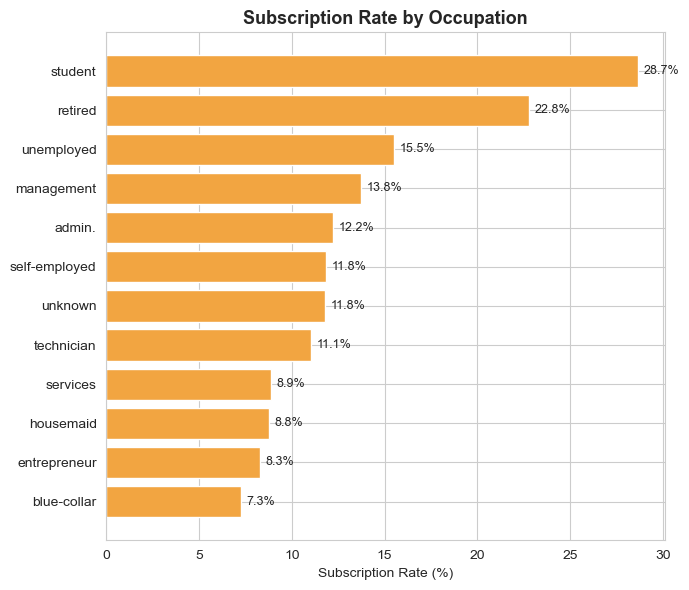

In [37]:
job_rate = (df.groupby('job')['y'].apply(lambda s: (s=='yes').mean()*100)).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7,6))
bars = ax.barh(job_rate.index, job_rate.values, color=COLORS[1])
for bar, val in zip(bars, job_rate.values):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
ax.set_title('Subscription Rate by Occupation', fontsize=13, fontweight='bold')
ax.set_xlabel('Subscription Rate (%)')
plt.tight_layout()
plt.savefig('chart_03_job_rate.png', bbox_inches='tight')
plt.show()

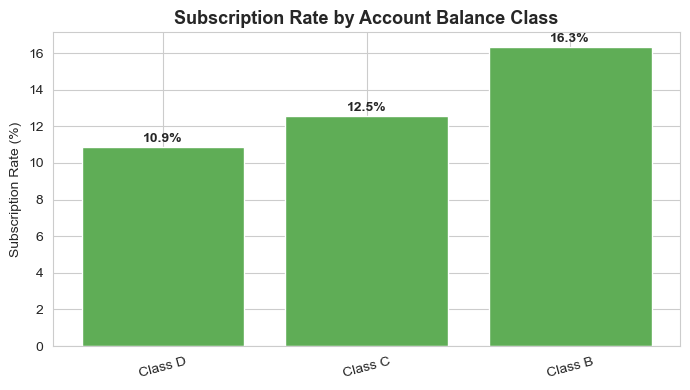

In [39]:
df['balance_class'] = df['balance'].apply(balanceator)
order = ['Class E (Low)','Class D','Class C','Class B','Class A (High)']
bal_rate = df.groupby('balance_class')['y'].apply(lambda s: (s=='yes').mean()*100).reindex(order)

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(bal_rate.index, bal_rate.values, color=COLORS[2])
for bar, val in zip(bars, bal_rate.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Subscription Rate by Account Balance Class', fontsize=13, fontweight='bold')
ax.set_ylabel('Subscription Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart_05_balance_class.png', bbox_inches='tight')
plt.show()

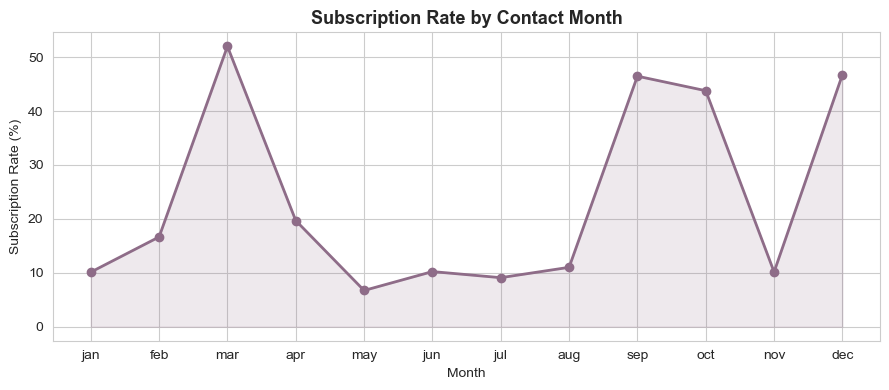

In [38]:
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_rate = df.groupby('month')['y'].apply(lambda s: (s=='yes').mean()*100).reindex(month_order)

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(month_rate.index, month_rate.values, marker='o', color=COLORS[4], linewidth=2)
ax.fill_between(range(len(month_rate)), month_rate.values, alpha=0.15, color=COLORS[4])
ax.set_title('Subscription Rate by Contact Month', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Subscription Rate (%)')
plt.tight_layout()
plt.savefig('chart_04_month_rate.png', bbox_inches='tight')
plt.show()

In [25]:
pred = dt.predict(indipendent_test)
print (classification_report(pred, dependent_test))


              precision    recall  f1-score   support

       False       0.90      0.91      0.90      5939
        True       0.29      0.28      0.28       843

    accuracy                           0.83      6782
   macro avg       0.60      0.59      0.59      6782
weighted avg       0.82      0.83      0.82      6782



In [29]:
params_dt = {
    "max_depth": [5, 10, 15, 20, 25, 30, None], # Maximum depth of the decision tree
    "criterion": ["gini","entropy"], # The quality criterion to measure the information gain when splitting nodes
    "min_samples_split": [2,3], # Minimum number of samples required to split an internal node
    "min_samples_leaf": [1,2] # Minimum number of samples required to be at a leaf node
}
model_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42), # Define the Decision Tree model
    params_dt, # Pass in the hyperparameters to be tuned from the dictionary we defined earlier
    cv=10, # Set the number of folds for cross-validation
    verbose=2
)
model_dt.fit(independent_train, dependent_train)

Fitting 10 folds for each of 56 candidates, totalling 560 fits
[CV] END criterion=gini, max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END criterion=gini, max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END criterion=gini, max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=5, min_samples_leaf=

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 3]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


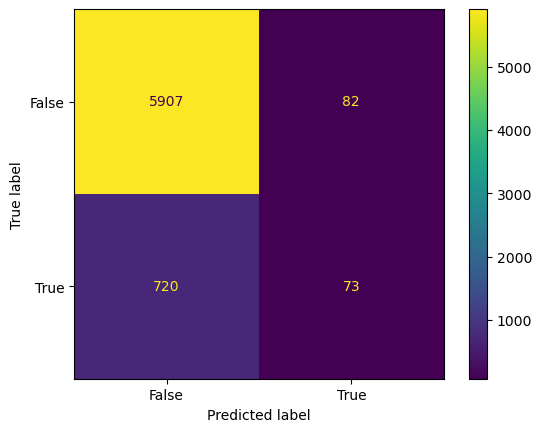

In [30]:
ConfusionMatrixDisplay.from_estimator(model_dt,indipendent_test,dependent_test)

In [31]:
pred_dt = model_dt.predict(indipendent_test)
print (classification_report(pred_dt, dependent_test))

              precision    recall  f1-score   support

       False       0.99      0.89      0.94      6627
        True       0.09      0.47      0.15       155

    accuracy                           0.88      6782
   macro avg       0.54      0.68      0.55      6782
weighted avg       0.97      0.88      0.92      6782

